<a href="https://colab.research.google.com/github/AnjaliKM-S/ICT-AKM_2026/blob/main/Case_Study_on_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Overview**

Load the dataset House_Pricing.csv
Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values.

In [113]:
##Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt
import seaborn as sns

#for scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [114]:
filepath = "/content/drive/MyDrive/ICT_AKM26/DATASETS/House_Pricing.csv"

In [115]:
customer_df = pd.read_csv(filepath)

In [4]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [5]:
customer_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
customer_df.head(5)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [7]:
##checking any missing values
customer_df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


# **Duplicate Removal**

Rows: Check for duplicate rows in the dataset, if any, and remove them.

Columns: Identify and drop duplicate columns, if any, based on their values.

In [8]:
#Before
customer_df.duplicated().sum()

np.int64(0)

In [9]:
customer_df.shape

(21613, 21)

In [10]:
customer_df.drop_duplicates(inplace = True)

In [11]:
#After Duplicate removal
customer_df.duplicated().sum()

np.int64(0)

In [14]:
#Identify and drop duplicate columns, if any, based on their values.
duplicate_columns = customer_df.T.duplicated()


In [13]:
customer_df.columns[duplicate_columns]

Index([], dtype='object')

In [15]:
customer_df = customer_df.loc[:, ~duplicate_columns]

# **Handling Missing Values**
Identify missing values in each column.
Handle missing values:

For numerical columns, use imputation techniques like mean/median imputation.

For categorical columns, fill with mode.
Document your approach for each feature with missing data.

In [16]:
customer_df.isna()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [17]:
customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [18]:
missing_percent = customer_df.isna().sum()/len(customer_df)*100

In [19]:
missing_percent.sort_values(ascending = True)

,0
ID,0.000000
Date House was Sold,0.000000
No of Bedrooms,0.000000
No of Floors,0.000000
Basement Area (in Sqft),0.000000
Overall Grade,0.000000
Condition of the House,0.000000
Waterfront View,0.000000
Renovated Year,0.000000
Age of House (in Years),0.000000


In [20]:
num_cols = customer_df.select_dtypes(include =["number"]).columns
cat_cols = customer_df.select_dtypes(include =["object"]).columns

In [21]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [22]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

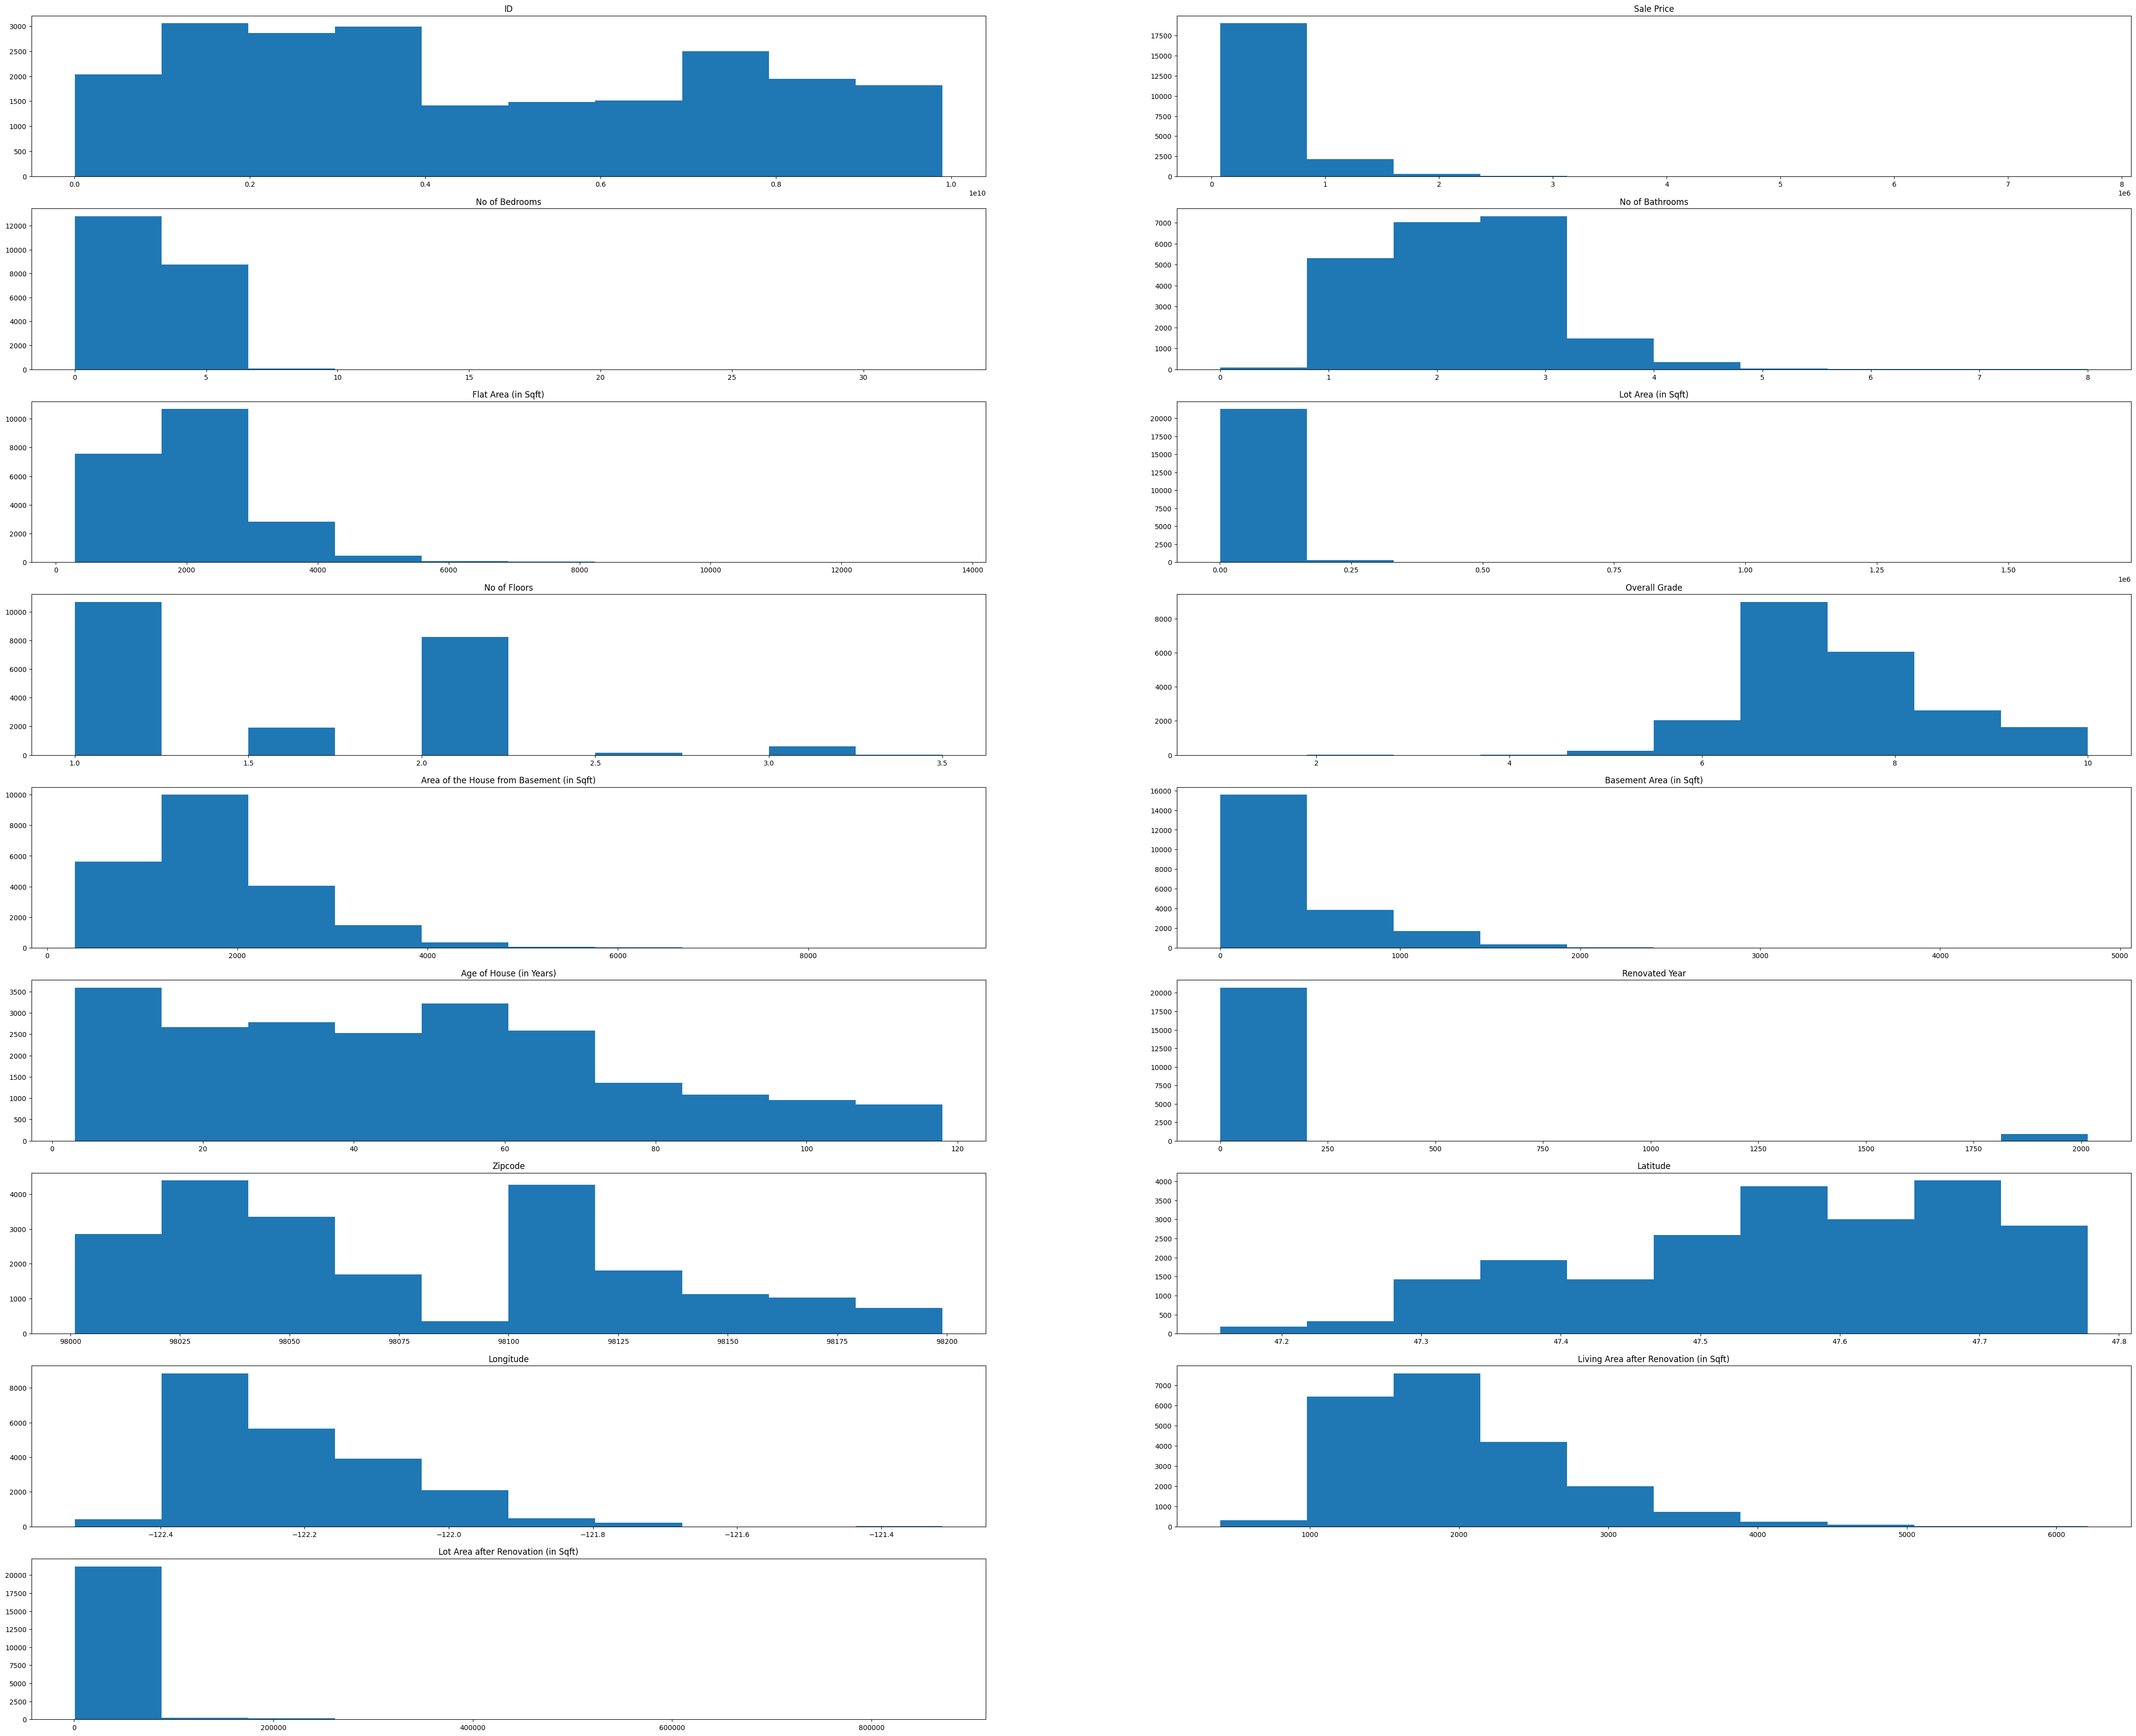

In [53]:
#Ploting all histograms in single plot
plt.figure(figsize=(55,50))
for i,col in enumerate(num_cols, 1):
  plt.subplot(10,2,i)
  plt.hist(customer_df[col])
  plt.title(col, fontsize=10)
  plt.title(col)

plt.show()


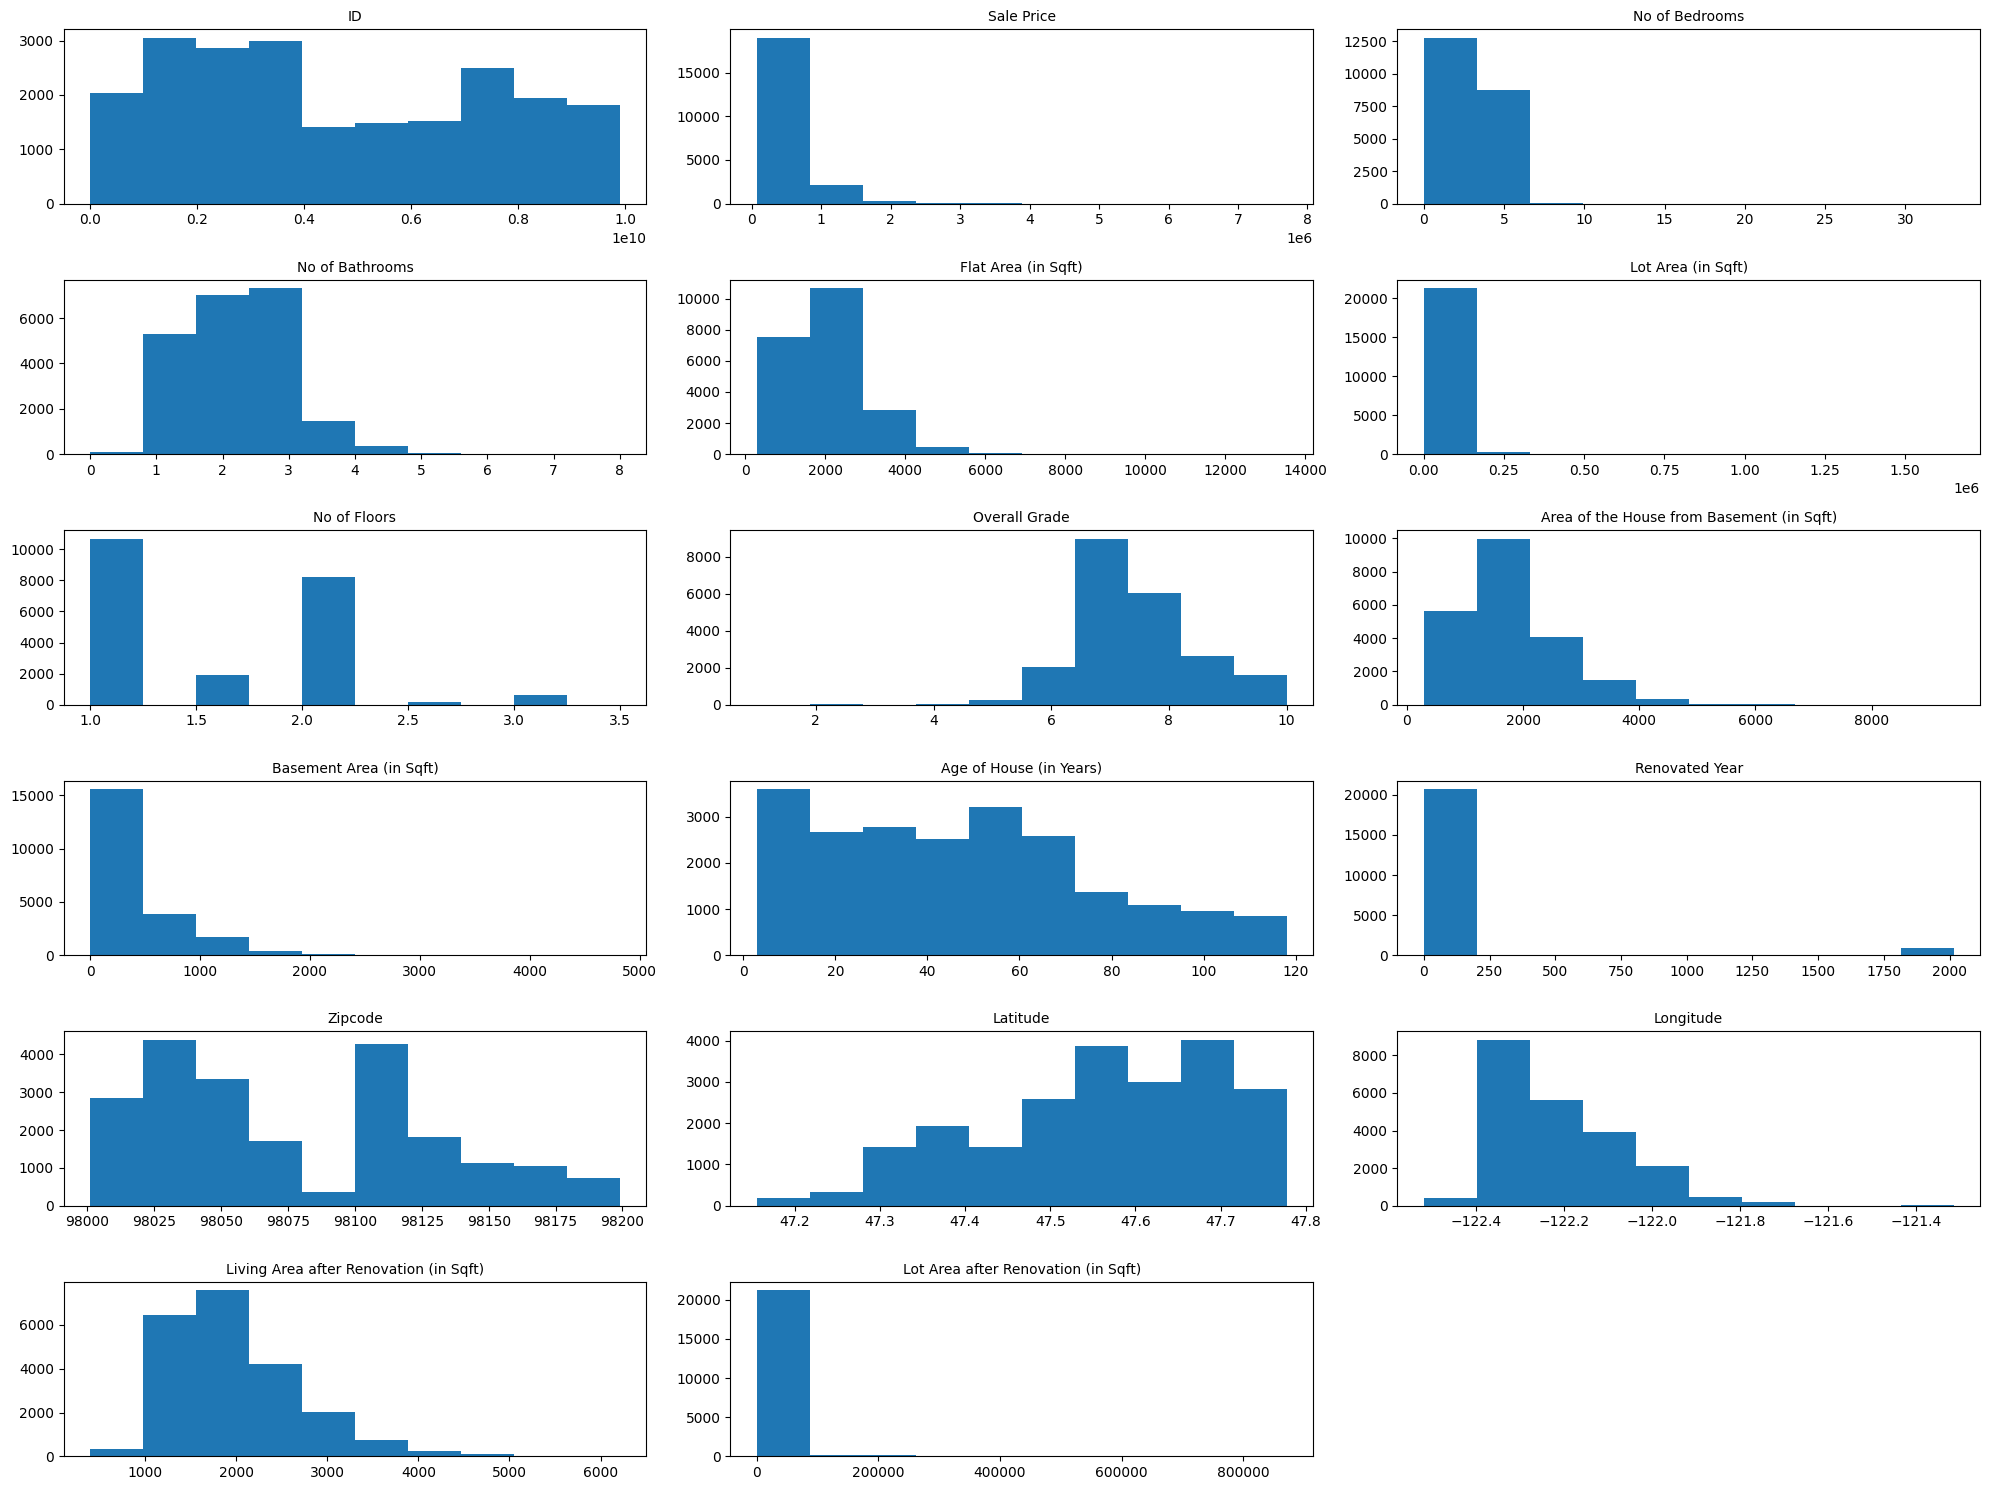

In [44]:
n = len(num_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(20, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(customer_df[col])
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

In [54]:
##from above histograms most of the values are skewed, so we can use median to replace every column
customer_df.isna().sum()


,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [55]:
customer_df['Sale Price'].fillna(customer_df['Sale Price'].median(),inplace = True)

/tmp/ipykernel_590/875424527.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Sale Price'].fillna(customer_df['Sale Price'].median(),inplace = True)


In [56]:
customer_df['No of Bathrooms'].fillna(customer_df['No of Bathrooms'].median(),inplace = True)

/tmp/ipykernel_590/3003090893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['No of Bathrooms'].fillna(customer_df['No of Bathrooms'].median(),inplace = True)


In [59]:
customer_df['Flat Area (in Sqft)'].fillna(customer_df['Flat Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_590/3442761135.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Flat Area (in Sqft)'].fillna(customer_df['Flat Area (in Sqft)'].median(),inplace = True)


In [60]:
customer_df['Lot Area (in Sqft)'].fillna(customer_df['Lot Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_590/2177590535.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Lot Area (in Sqft)'].fillna(customer_df['Lot Area (in Sqft)'].median(),inplace = True)


In [64]:
customer_df['Area of the House from Basement (in Sqft)'].fillna(customer_df['Area of the House from Basement (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_590/2062358559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Area of the House from Basement (in Sqft)'].fillna(customer_df['Area of the House from Basement (in Sqft)'].median(),inplace = True)


In [ ]:
#customer_df['No of Times Visited'].fillna(customer_df['No of Times Visited'].median(),inplace = True)

##---The column ‘No of Times Visited’ had excessive missing values (~99%), so it was dropped instead of imputation to avoid introducing bias.


customer_df.drop(columns=['No of Times Visited'], inplace=True)

In [66]:
customer_df['Latitude'].fillna(customer_df['Latitude'].median(),inplace = True)

/tmp/ipykernel_590/349148624.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Latitude'].fillna(customer_df['Latitude'].median(),inplace = True)


In [67]:
customer_df['Longitude'].fillna(customer_df['Longitude'].median(),inplace = True)

/tmp/ipykernel_590/512564169.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Longitude'].fillna(customer_df['Longitude'].median(),inplace = True)


In [68]:
customer_df['Living Area after Renovation (in Sqft)'].fillna(customer_df['Living Area after Renovation (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_590/2443893807.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Living Area after Renovation (in Sqft)'].fillna(customer_df['Living Area after Renovation (in Sqft)'].median(),inplace = True)


In [110]:
#After handling missing values
customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Condition of the House,0
Overall Grade,0


####For categorical columns, fill with mode.

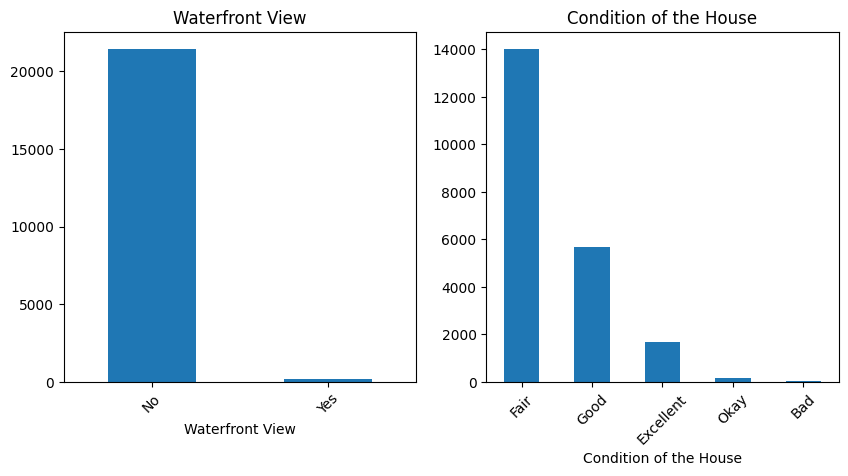

In [116]:
# plots to understand categorical value distribution
plt.figure(figsize= (10,10))
for i,col in enumerate(cat_cols, 1):
  plt.subplot(2,2, i)
  customer_df[col].value_counts().plot(kind ='bar')
  plt.title(col)
  plt.xticks(rotation = 45)
plt.tight_layout
plt.show()

In [71]:
for col in cat_cols:
    if customer_df[col].isnull().sum() > 0:
        customer_df[col].fillna(customer_df[col].mode()[0], inplace=True)

In [72]:
####since replacing the caegorical null value with mode will introduce data imbalance we go for the rows with null values in categorical coulmns
#removing rows with null values in all columns
customer_df.dropna(axis = 0, inplace= True)

In [73]:
customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


###Missing values were handled based on data type. Numerical features were imputed using median to reduce the effect of outliers. Categorical features such as Zipcode were imputed using mode (most frequent value). Columns with excessive missing values, such as “No of Times Visited”, were dropped to maintain data quality.

##Scaling Numerical Variables

Identify all numerical columns (excluding the target variable SalePrice).

Scale these features using techniques like Min-Max scaling or Standard scaling.

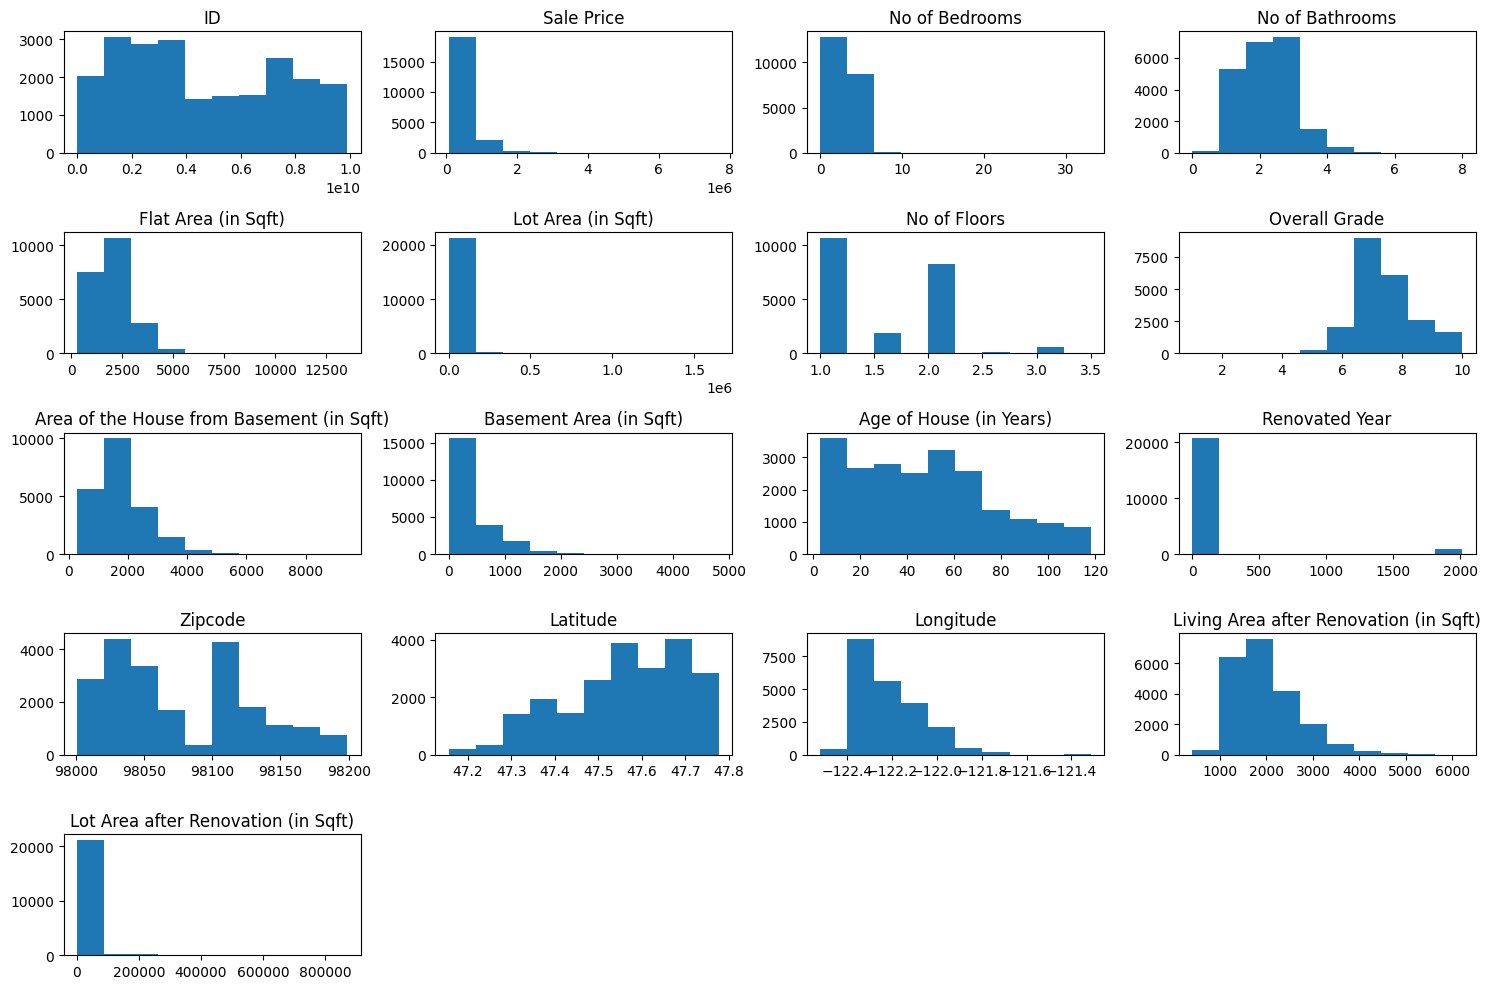

In [77]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5,4,i)   # 20 slots
    plt.hist(customer_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [82]:
num_cols = customer_df.select_dtypes(include =["number"]).columns
min_max_scaler = MinMaxScaler()
num_cols = num_cols.drop('Sale Price')


In [83]:
scaler = MinMaxScaler()

customer_df[num_cols] = scaler.fit_transform(customer_df[num_cols])

In [84]:
#After scaling

customer_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,0.462602,5.401817e+05,0.102147,0.264345,0.135084,0.008835,0.197724,0.735941,0.164289,0.060479,0.382564,0.041887,0.388572,0.650069,0.253412,0.273194,0.013919
std,0.290592,3.673570e+05,0.028184,0.096259,0.069306,0.025090,0.215996,0.122827,0.090782,0.091821,0.255421,0.199345,0.270224,0.222876,0.116966,0.117947,0.031364
min,0.000000,7.500000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.214370,3.220000e+05,0.090909,0.218750,0.086038,0.002738,0.000000,0.666667,0.098684,0.000000,0.156522,0.000000,0.161616,0.506836,0.158638,0.187747,0.005111
50%,0.394376,4.500000e+05,0.090909,0.281250,0.122264,0.004299,0.200000,0.666667,0.139254,0.000000,0.347826,0.000000,0.323232,0.668972,0.240033,0.247978,0.008005
75%,0.738246,6.450000e+05,0.121212,0.312500,0.170566,0.006157,0.400000,0.777778,0.210526,0.116183,0.556522,0.000000,0.590909,0.839794,0.327243,0.337463,0.010835
max,1.000000,7.700000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


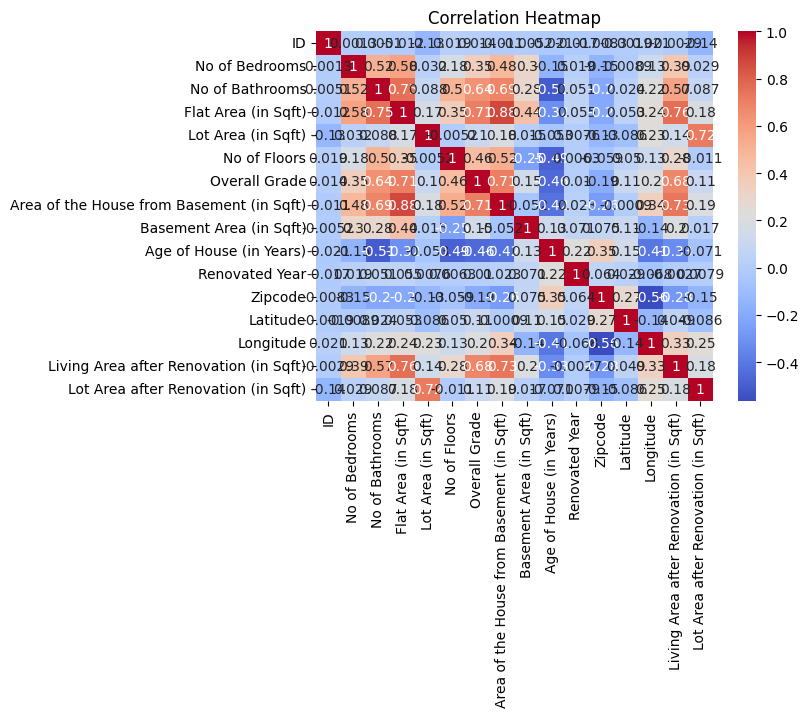

In [85]:
#correlation after scaling
corr_matrix = customer_df[num_cols].corr(method ='pearson')
corr_matrix

sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [86]:
customer_df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.720103,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,0.0,No,Twice,...,0.666667,0.097588,0.000000,0.521739,0.000000,0.893939,0.571498,0.217608,0.161934,0.005742
1,0.647853,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,0.4,No,Twice,...,0.666667,0.206140,0.082988,0.556522,0.988089,0.626263,0.908959,0.166113,0.222165,0.008027
2,0.568795,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,0.0,No,Twice,...,0.555556,0.052632,0.000000,0.713043,0.000000,0.136364,0.936143,0.237542,0.399415,0.008513
3,0.251157,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,0.0,No,Twice,...,0.666667,0.083333,0.188797,0.434783,0.000000,0.681818,0.586939,0.104651,0.165376,0.004996
4,0.197333,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,0.0,No,Twice,...,0.777778,0.152412,0.000000,0.243478,0.000000,0.368687,0.741354,0.393688,0.241094,0.007871


# **Encoding Categorical Variables**
Identify all categorical columns in the dataset.
Apply appropriate encoding techniques:
Use One-Hot Encoding for nominal categories.
Use Label Encoding for ordinal categories, if applicable.

In [87]:
cat_cols = customer_df.select_dtypes(include =["object"]).columns

In [88]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [89]:
#One-hot encoding for waterfront view, as No of times visited dropped eariler and Date House was Sold; datetime (not for encoding)
customer_df = pd.get_dummies(customer_df, columns=['Waterfront View'], dtype =int)

In [90]:
label_encoder = LabelEncoder()
customer_df['Condition of the House'] = label_encoder.fit_transform(customer_df['Condition of the House'])

# Outlier Removal
Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).

Remove outliers from these features if they are not representative of typical house prices.

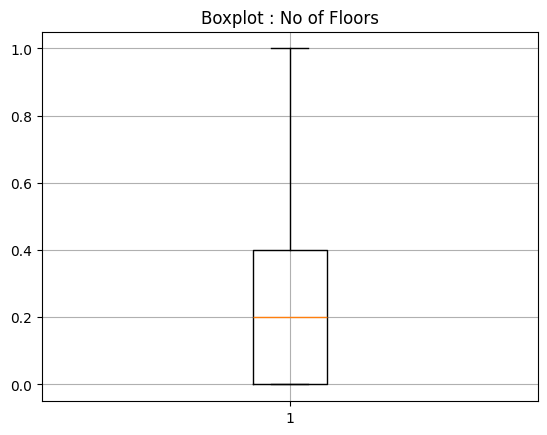

In [95]:
plt.boxplot(customer_df['No of Floors'])
plt.title('Boxplot : No of Floors')
plt.grid()
plt.show()

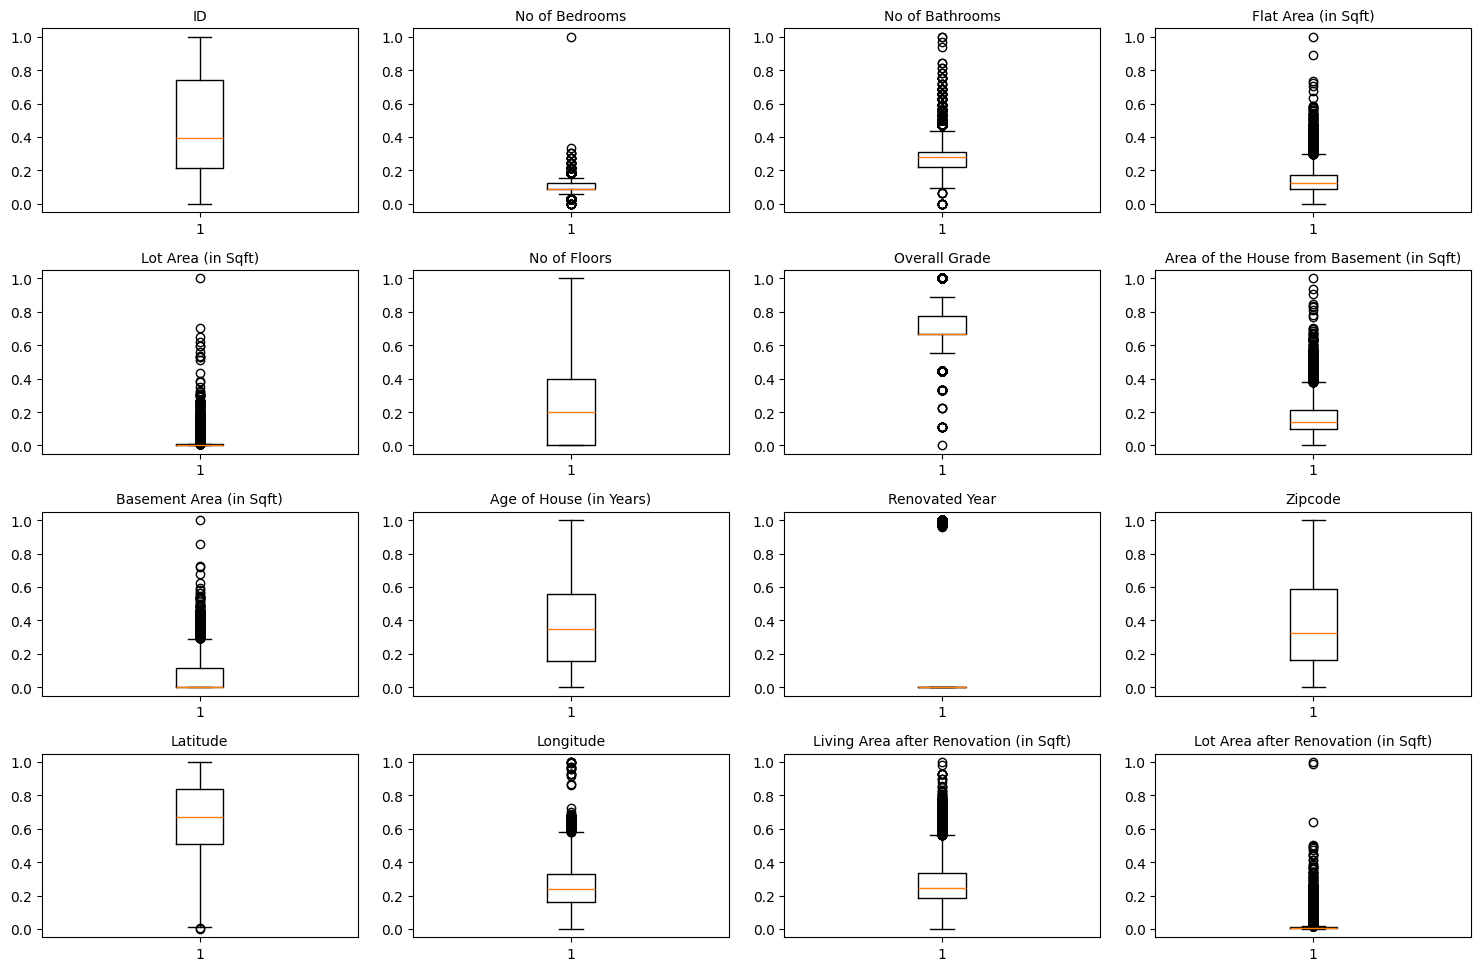

In [93]:
plt.figure(figsize=(15,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)   # 20 slots
    plt.boxplot(customer_df[col])
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

In [94]:
Q1 = customer_df[num_cols].quantile(0.25)

Q3 = customer_df[num_cols].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3+ (1.5 * IQR)
lower_limit = Q1- (1.5 * IQR)

outliers = ((customer_df[num_cols] > upper_limit)|(customer_df[num_cols] < lower_limit)).any(axis = 1)

outliers_df = customer_df[outliers]
outlier_percentage = len(outliers_df)* 100/len(customer_df)

print('percentage of outliers in the dataframe: ', outlier_percentage)

percentage of outliers in the dataframe:  25.475408319067228


In [96]:
customer_df = customer_df[~outliers]

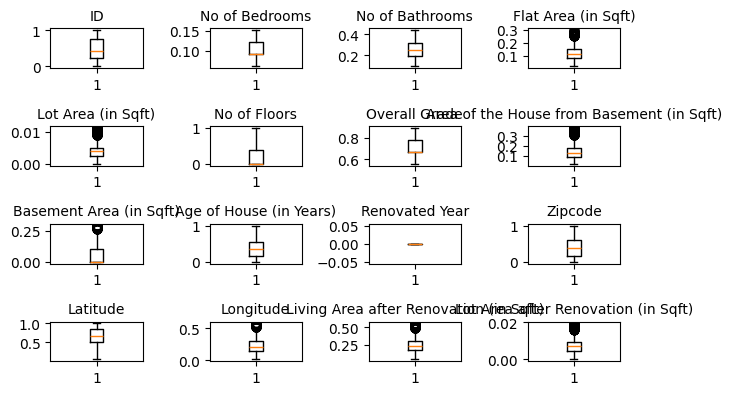

In [97]:
#After outlier removal;
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)   # 20 slots
    plt.boxplot(customer_df[col])
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

# Train-Test Split
Set aside the SalePrice column as the target variable.

Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.


In [99]:
##Target = Sale Price
X = customer_df.drop('Sale Price', axis=1)
y = customer_df['Sale Price']

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # for reproducibility
)

In [103]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12885, 21)
X_test: (3222, 21)
y_train: (12885,)
y_test: (3222,)


In [ ]:
#The dataset was split into training and testing sets using an 80:20 ratio. The target variable “Sale Price” was separated from the feature set. The train_test_split function from sklearn was used with a fixed random state to ensure reproducibility of results.